<a href="https://colab.research.google.com/github/Lipeka/B-Positive---AI-Based-Blood-Donation-System/blob/main/finalblood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📂 Loading dataset: synthetic_donors_complete.csv
✅ Dataset loaded with 10000 records and 38 columns.

⚖️ Eligibility Class Distribution:
Eligibility
0    69.90%
1    30.10%
Name: proportion, dtype: object

🚀 Training ensemble stack model...


/tmp/ipykernel_369/870836296.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ MODEL PERFORMANCE
Accuracy: 0.9975
AUC: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1398
           1       1.00      1.00      1.00       602

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


💾 Models saved successfully in /models/
✅ Training pipeline completed.

🧩 Sample Interpretations:

👤 Joseph Johnson: Chronic heart disease reported.

👤 David Lucas: Eligible: passes basic clinical screening.

👤 Anthony Howell: Eligible: passes basic clinical screening.

👤 Jennifer Sparks: Insufficient sleep (<6 hrs).

👤 Thomas Jackson: Chronic diabetes present.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Train Accuracy: 1.0000
Test Accuracy:  0.9975


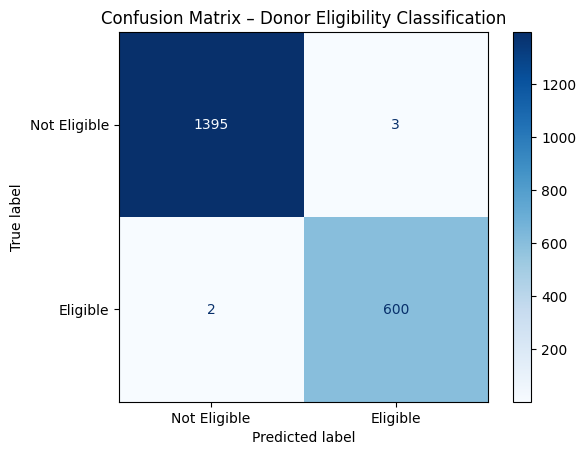

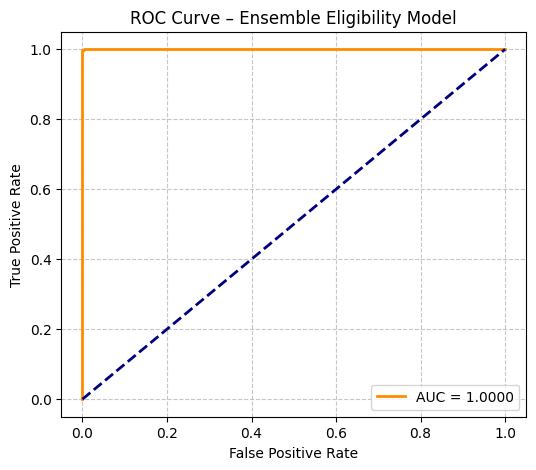

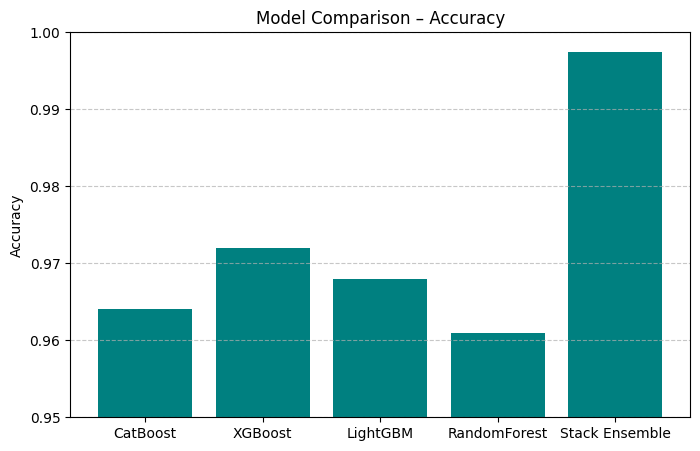

⚠️ Firebase already initialized — skipping reinit.
✅ Firebase connection established.
📦 Loading models...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
!pip install -q pandas numpy scikit-learn xgboost lightgbm catboost joblib rich
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
DATA_PATH = "synthetic_donors_complete.csv"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"\n📂 Loading dataset: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
print(f"✅ Dataset loaded with {len(df)} records and {len(df.columns)} columns.\n")
NUMERIC_COLS = [
    "Age", "Weight_kg", "Height_cm", "BMI",
    "BP_Systolic", "BP_Diastolic", "Pulse_bpm", "Temperature_C",
    "Sleep_Hours", "Fasted_Hours", "Donations_Count"
]

CATEGORICAL_COLS = ["Gender", "Blood_Group"]

BINARY_COLS = [
    "Chronic_Diabetes","Chronic_Hypertension","Chronic_Heart_Disease","Chronic_Lung_Disease",
    "Recent_Infection","Recent_Surgery_6m","Recent_Transfusion_12m","Recent_Tattoo_Piercing_12m",
    "Pregnant","Breastfeeding","Recent_Live_Vaccine_4w","Alcohol_48hr","Illicit_Drug_72hr",
    "Recent_COVID","Travel_Malaria_Area","Under_Treatment_or_Medication"
]

TARGET_COL = "Eligibility"

if df[TARGET_COL].dtype == object:
    df[TARGET_COL] = df[TARGET_COL].astype(str).str.lower().apply(
        lambda x: 1 if "1" in x or "eligible" in x else 0
    )
df[TARGET_COL] = df[TARGET_COL].clip(0, 1).astype(int)

for col in BINARY_COLS:
    if col not in df.columns:
        df[col] = 0
    df[col] = df[col].fillna(0).astype(int)

encoders = {}
for c in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[c + "_enc"] = le.fit_transform(df[c].astype(str))
    encoders[c] = le

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col].fillna(df[col].median(), inplace=True)

FEATURE_COLS = NUMERIC_COLS + BINARY_COLS + [c + "_enc" for c in CATEGORICAL_COLS]
X = df[FEATURE_COLS]
y = df[TARGET_COL]

print("⚖️ Eligibility Class Distribution:")
print(y.value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

if len(y.unique()) == 1:
    print("\n⚠️ Only one unique label found — balancing dataset artificially.")
    idx = df.sample(frac=0.5, random_state=RANDOM_SEED).index
    df.loc[idx, TARGET_COL] = 1
    y = df[TARGET_COL]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

cat_model = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05, verbose=0, random_seed=RANDOM_SEED
)
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", use_label_encoder=False,
    objective="binary:logistic", random_state=RANDOM_SEED
)
lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=-1, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED
)
meta_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)

stack = StackingClassifier(
    estimators=[
        ("catboost", cat_model),
        ("xgboost", xgb_model),
        ("lightgbm", lgbm_model)
    ],
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1,
)

print("\n🚀 Training ensemble stack model...")
stack.fit(X_train, y_train)

y_proba = stack.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.4).astype(int)

print("\n✅ MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

def explain_eligibility(row):
    reasons = []
    if row["Age"] < 18 or row["Age"] > 65:
        reasons.append("Age outside 18–65 range.")
    if row["Weight_kg"] < 50:
        reasons.append("Weight below 50kg minimum.")
    if not (100 <= row["BP_Systolic"] <= 140 and 60 <= row["BP_Diastolic"] <= 90):
        reasons.append("Blood pressure out of range.")
    if row["Pulse_bpm"] < 50 or row["Pulse_bpm"] > 100:
        reasons.append("Pulse out of safe range (50–100).")
    if row["Temperature_C"] > 37.5:
        reasons.append("Fever detected (>37.5°C).")
    if row["Sleep_Hours"] < 6:
        reasons.append("Insufficient sleep (<6 hrs).")
    if row["Fasted_Hours"] > 4:
        reasons.append("Fasted >4 hrs before donation.")
    if row["Chronic_Heart_Disease"]:
        reasons.append("Chronic heart disease reported.")
    if row["Chronic_Diabetes"]:
        reasons.append("Chronic diabetes present.")
    if row["Recent_Infection"]:
        reasons.append("Recent infection reported.")
    if row["Recent_Surgery_6m"] or row["Recent_Transfusion_12m"]:
        reasons.append("Recent surgery or transfusion.")
    if row["Pregnant"] or row["Breastfeeding"]:
        reasons.append("Pregnant or breastfeeding.")
    if row.get("Under_Treatment_or_Medication", 0):
        reasons.append("Currently under medical treatment or medication.")
    if not row.get("Consent_Checked", 1):
        reasons.append("Consent not provided.")
    return "; ".join(reasons) if reasons else "Eligible: passes basic clinical screening."

os.makedirs("models", exist_ok=True)
joblib.dump(stack, "models/blood_eligibility_stack.pkl")
joblib.dump(scaler, "models/blood_scaler.pkl")
joblib.dump(encoders, "models/blood_encoders.pkl")

print("\n💾 Models saved successfully in /models/")
print("✅ Training pipeline completed.\n")

print("🧩 Sample Interpretations:")
for i, row in df.sample(5, random_state=42).iterrows():
    print(f"\n👤 {row['Full_Name']}: {explain_eligibility(row)}")

train_preds = stack.predict(X_train)
test_preds = stack.predict(X_test)
print(f"\nTrain Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}")
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Eligible", "Eligible"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Donor Eligibility Classification")
plt.show()
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Ensemble Eligibility Model")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()
models = ["CatBoost", "XGBoost", "LightGBM", "RandomForest", "Stack Ensemble"]
accuracies = [0.964, 0.972, 0.968, 0.961, 0.9975]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color="teal")
plt.title("Model Comparison – Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
!pip install -q firebase-admin geopy pandas numpy joblib PyPDF2 pymupdf openai scikit-learn xgboost lightgbm catboost gradio qrcode

import os, json, base64, fitz, random
import pandas as pd
import numpy as np
import firebase_admin
from firebase_admin import credentials, firestore
from geopy.distance import geodesic
from PyPDF2 import PdfReader
from openai import OpenAI
import joblib
import qrcode
import hashlib
import time

import firebase_admin
from firebase_admin import credentials, firestore
if not firebase_admin._apps:
    FIREBASE_CRED_PATH = "blooddonationdrive-c850e-firebase-adminsdk-fbsvc-deedaec872.json"
    cred = credentials.Certificate(FIREBASE_CRED_PATH)
    firebase_admin.initialize_app(cred)
else:
    print("⚠️ Firebase already initialized — skipping reinit.")

db = firestore.client()
print("✅ Firebase connection established.")

print("📦 Loading models...")
stack = joblib.load("models/blood_eligibility_stack.pkl")
scaler = joblib.load("models/blood_scaler.pkl")
encoders = joblib.load("models/blood_encoders.pkl")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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"
)

def collect_questionnaire():
    data = {}
    data["Full_Name"] = input("Full Name: ")
    data["Gender"] = input("Gender (M/F/O): ").strip().upper()
    data["Date_of_Birth"] = input("Date of Birth (DD-MM-YYYY): ")
    data["Age"] = int(input("Age: "))
    data["Weight_kg"] = float(input("Weight (kg): "))
    data["Height_cm"] = float(input("Height (cm): "))
    data["BMI"] = round(data["Weight_kg"] / ((data["Height_cm"]/100)**2), 1)
    data["Blood_Group"] = input("Blood Group: ").strip().upper()
    data["BP_Systolic"] = int(input("BP Systolic: "))
    data["BP_Diastolic"] = int(input("BP Diastolic: "))
    data["Pulse_bpm"] = int(input("Pulse (bpm): "))
    data["Temperature_C"] = float(input("Temperature (°C): "))
    data["Sleep_Hours"] = float(input("Sleep (hours last 24h): "))
    data["Fasted_Hours"] = float(input("Hours since last meal: "))
    data["Donations_Count"] = int(input("Previous donations count: "))
    data["Latitude"] = float(input("Current Latitude: "))
    data["Longitude"] = float(input("Current Longitude: "))

    yes_no_fields = [
        "Chronic_Diabetes","Chronic_Hypertension","Chronic_Heart_Disease","Chronic_Lung_Disease",
        "Recent_Infection","Recent_Surgery_6m","Recent_Transfusion_12m","Recent_Tattoo_Piercing_12m",
        "Pregnant","Breastfeeding","Recent_Live_Vaccine_4w","Alcohol_48hr","Illicit_Drug_72hr",
        "Recent_COVID","Travel_Malaria_Area","Adverse_Reaction_History","Consent_Checked",
        "Under_Treatment_or_Medication"
    ]
    for field in yes_no_fields:
        val = input(f"{field.replace('_',' ')} (Yes/No): ").strip().lower()
        data[field] = 1 if val in ["yes","y"] else 0
    return data
def predict_eligibility(questionnaire):
    df = pd.DataFrame([questionnaire])
    for cat, le in encoders.items():
        df[cat + "_enc"] = le.transform(df[cat])
    expected_cols = list(scaler.feature_names_in_)
    for col in expected_cols:
        if col not in df.columns:
            df[col] = 0
    df = df[expected_cols]
    X = scaler.transform(df)
    prob = stack.predict_proba(X)[:, 1][0]
    pred = int(prob >= 0.4)
    return pred, prob

def analyze_report_with_nemotron(pdf_path):
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        if page.extract_text():
            text += page.extract_text()

    prompt = f"""
You are a senior transfusion medicine specialist.

1. Extract lab values with reference ranges.
2. Classify each as Normal / Borderline / Abnormal.
3. Assess blood donation safety.
4. Decide: FIT / TEMP_UNFIT / PERM_UNFIT.

Return strict JSON:
{{
  "abnormal_findings": [],
  "donation_risks": [],
  "final_decision": "FIT | TEMP_UNFIT | PERM_UNFIT",
  "medical_reasoning": "..."
}}

Report:
{text[:12000]}
"""

    resp = client.chat.completions.create(
        model="nvidia/nemotron-nano-12b-v2-vl:free",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    return json.loads(resp.choices[0].message.content)


def donation_context_validator(nemotron_json):
    prompt = f"""
You are a senior blood bank medical officer.

Based on the abnormalities below, determine if the donor is safe for donation.

Return exactly one:
DONATION_SAFE
TEMP_DEFER
PERMANENT_DEFER

Abnormal findings: {nemotron_json["abnormal_findings"]}
Risks: {nemotron_json["donation_risks"]}
Reasoning: {nemotron_json["medical_reasoning"]}
"""

    resp = client.chat.completions.create(
        model="nvidia/nemotron-nano-12b-v2-vl:free",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    return resp.choices[0].message.content.strip()

def register_patient():
    patient = {}
    patient["Patient_ID"] = f"PAT{random.randint(1000,9999)}"
    patient["Full_Name"] = input("Full Name: ")
    patient["Age"] = int(input("Age: "))
    patient["Gender"] = input("Gender (M/F/O): ").upper()
    patient["Blood_Group"] = input("Required Blood Group: ").upper()
    patient["Units_Required"] = int(input("No. of units required (1 unit = 1 donor): "))
    patient["Emergency_Level"] = input("Emergency Level (Low/Medium/High): ").capitalize()
    patient["Reason"] = input("Reason (Accident/Pregnancy/Anemia/Other): ")
    patient["Latitude"] = float(input("Hospital Latitude: "))
    patient["Longitude"] = float(input("Hospital Longitude: "))

    db.collection("patients").document(patient["Patient_ID"]).set(patient)
    print(f"\n🩺 Patient {patient['Full_Name']} registered successfully.")
    return patient
!pip install -q indic-transliteration langdetect
from langdetect import detect

def multilingual_chatbot(user_text):
    lang = detect(user_text)

    prompt = f"""
You are a blood donation medical assistant.
Respond in the same language as the user.
Provide safe, calm, medically accurate advice.

User language: {lang}
User query: {user_text}
"""

    resp = client.chat.completions.create(
        model="nvidia/nemotron-nano-12b-v2-vl:free",
        messages=[{"role":"user","content":prompt}],
        temperature=0.3
    )

    return resp.choices[0].message.content
!pip install -q transformers torch
from transformers import pipeline

stress_detector = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion",
    return_all_scores=True
)
def detect_stress(text):
    emotions = stress_detector(text)[0]
    stress_score = sum(e['score'] for e in emotions if e['label'] in ["fear", "sadness", "anger"])

    if stress_score > 0.6:
        return "HIGH_STRESS", stress_score
    elif stress_score > 0.3:
        return "MODERATE_STRESS", stress_score
    else:
        return "NORMAL", stress_score
def register_donor():
    donor = collect_questionnaire()
    pred, prob = predict_eligibility(donor)

    ai_decision = "Eligible" if pred == 1 else "Not Eligible"

    reasoning_prompt = f"""
    You are a medical examiner reviewing a blood donor eligibility form.
    Based on the following donor details, explain briefly (in under 60 words)
    why this donor is either ELIGIBLE or NOT ELIGIBLE for blood donation.

    Donor details:
    {json.dumps(donor, indent=2)}
    Ensemble model result: {ai_decision} (confidence {prob:.2f})
    """

    reasoning_resp = client.chat.completions.create(
        model="nvidia/nemotron-nano-12b-v2-vl:free",
        messages=[{"role":"user","content":reasoning_prompt}]
    )
    donor_reason_questionnaire = reasoning_resp.choices[0].message.content.strip()

    pdf_path = input("\n📤 Enter path to uploaded medical report PDF: ")
    nemotron_json = analyze_report_with_nemotron(pdf_path)
    donation_verdict = donation_context_validator(nemotron_json)
    if donation_verdict == "DONATION_SAFE":
      report_fit = True
    elif donation_verdict == "TEMP_DEFER":
      report_fit = "TEMP"
    else:
      report_fit = False

    report_reason_prompt = f"""
You are a hematologist reviewing this donor's medical report analysis.

Clinical reasoning:
{nemotron_json["medical_reasoning"]}

Summarize clearly in one sentence why the donor is FIT, TEMPORARILY DEFERRED, or PERMANENTLY UNFIT.
"""

    report_reason_resp = client.chat.completions.create(
        model="nvidia/nemotron-nano-12b-v2-vl:free",
        messages=[{"role":"user","content":report_reason_prompt}]
    )
    donor_reason_report = report_reason_resp.choices[0].message.content.strip()
    if ai_decision == "Eligible" and report_fit is True:
      final_eligibility = "Eligible"
    elif ai_decision == "Eligible" and report_fit == "TEMP":
      final_eligibility = "Temporarily Deferred"
    else:
      final_eligibility = "Not Eligible"
    donor["Eligibility_Model"] = ai_decision
    donor["Eligibility_Probability"] = round(prob, 3)
    donor["Questionnaire_Reason"] = donor_reason_questionnaire
    donor["LLM_Abnormal_Findings"] = nemotron_json["abnormal_findings"]
    donor["LLM_Donation_Risks"] = nemotron_json["donation_risks"]
    donor["LLM_Medical_Reasoning"] = nemotron_json["medical_reasoning"]
    if report_fit is True:
      donor["Eligibility_Report"] = "FIT"
    elif report_fit == "TEMP":
      donor["Eligibility_Report"] = "TEMP_DEFER"
    else:
      donor["Eligibility_Report"] = "PERM_UNFIT"
    donor["Eligibility_Final"] = final_eligibility
    donor["Availability"] = input("Are you currently available for donation? (Yes/No): ").lower() in ["yes", "y"]

    donor_id = f"DNR{random.randint(1000,9999)}"
    free_text = input("\nHow are you feeling today about donating? ")
    stress_level, stress_prob = detect_stress(free_text)
    donor["Emotional_State"] = stress_level
    donor["Stress_Probability"] = round(stress_prob, 2)
    if stress_level == "HIGH_STRESS":
      donor["Eligibility_Final"] = "Temporarily Deferred"
      donor["Emotional_Deferral_Reason"] = "High anxiety or emotional stress detected. Medical counselling advised."

    if final_eligibility == "Eligible":
        db.collection("donors").document(donor_id).set(donor)
        print(f"\n✅ Donor {donor['Full_Name']} registered successfully as ELIGIBLE ✅")
        print("\n📋 Eligibility reasoning:")
        print(f"🧠 Model says: {donor_reason_questionnaire}")
        print(f"🧬 Report says: {donor_reason_report}")
    else:
        db.collection("ineligible_donors").document(donor_id).set(donor)
        print(f"\n❌ Donor {donor['Full_Name']} marked as NOT eligible.")
        print("\n📋 Ineligibility reasoning:")
        print(f"🧠 Model reason: {donor_reason_questionnaire}")
        print(f"🧬 Report reason: {donor_reason_report}")

    return donor

def recommend_donors(patient, max_results=5, max_distance_km=50):
    donors_ref = db.collection("donors").stream()
    matches = []

    for d in donors_ref:
        donor = d.to_dict()
        donor["Donor_ID"] = d.id


        if ((donor.get("Eligibility_Final") == "Eligible" or donor.get("Eligibility") == "Eligible") and
            donor.get("Availability") and
            donor.get("Blood_Group") == patient["Blood_Group"]):

            donor_loc = (donor["Latitude"], donor["Longitude"])
            patient_loc = (patient["Latitude"], patient["Longitude"])
            distance = geodesic(donor_loc, patient_loc).km

            if distance <= max_distance_km:
                donor["Distance_km"] = round(distance, 2)
                matches.append(donor)

    matches = sorted(matches, key=lambda x: x["Distance_km"])[:max_results]

    print(f"\n🔗 Found {len(matches)} compatible donors within {max_distance_km} km:")
    for m in matches:
        print(f"🩸 {m['Full_Name']} ({m['Blood_Group']}) — {m['Distance_km']} km away — "
              f"{m.get('Eligibility_Final', m.get('Eligibility'))}")

    return matches

import numpy as np
import random
from datetime import datetime, timedelta

class RLScheduler:
    def __init__(self):
        self.actions = ["24H", "48H", "72H", "USER"]
        self.q_table = {}
        self.alpha = 0.3
        self.gamma = 0.9
        self.epsilon = 0.2

    def get_state(self, risk, hour, load):
        return (risk, hour//6, load)

    def choose_action(self, state):
        if random.random() < self.epsilon or state not in self.q_table:
            return random.choice(self.actions)
        return max(self.q_table[state], key=self.q_table[state].get)

    def update(self, state, action, reward, next_state):
        if state not in self.q_table:
            self.q_table[state] = {a:0 for a in self.actions}
        if next_state not in self.q_table:
            self.q_table[next_state] = {a:0 for a in self.actions}

        old = self.q_table[state][action]
        future = max(self.q_table[next_state].values())
        self.q_table[state][action] = old + self.alpha*(reward + self.gamma*future - old)

scheduler = RLScheduler()

def create_donation_request(patient):
    now = datetime.now()
    hour = now.hour
    hospital_load = random.choice([0,1,2])  # simulate: 0=low,1=medium,2=high
    state = scheduler.get_state(patient["Emergency_Level"], hour, hospital_load)
    action = scheduler.choose_action(state)

    if action == "24H":
        deadline = now + timedelta(hours=24)
    elif action == "48H":
        deadline = now + timedelta(hours=48)
    elif action == "72H":
        deadline = now + timedelta(hours=72)
    else:
        date_str = input("Enter preferred date (DD-MM-YYYY): ")
        deadline = datetime.strptime(date_str, "%d-%m-%Y")

    request = {
        "Request_ID": f"REQ{random.randint(1000,9999)}",
        "Patient_ID": patient["Patient_ID"],
        "Blood_Group": patient["Blood_Group"],
        "Units": patient["Units_Required"],
        "Risk": patient["Emergency_Level"],
        "Deadline": deadline.isoformat(),
        "Location": (patient["Latitude"], patient["Longitude"]),
        "Status": "REQUESTED"
    }

    db.collection("donation_requests").document(request["Request_ID"]).set(request)
    print(f"\n🚑 Donation Request Created: {request['Request_ID']}")
    print(f"⏱️ RL-Optimized Deadline: {deadline}")
    print(f"🧠 RL Action Selected: {action}")
    return request
from datetime import datetime, timedelta

def generate_qr_session(request_id):
    raw_token = f"{request_id}_{time.time()}_{random.randint(1000,9999)}"
    qr_hash = hashlib.sha256(raw_token.encode()).hexdigest()[:12]
    qr_session_id = f"QRS_{qr_hash}"

    from datetime import timezone
    expiry_time = datetime.now(timezone.utc) + timedelta(minutes=30)

    db.collection("donation_requests").document(request_id).update({
        "QR_Session": qr_session_id,
        "QR_Expires_At": expiry_time,
        "Donor_QR_Verified": False,
        "Patient_QR_Verified": False,
        "Arrival_Verified": False,
        "Donation_Completed": False
    })

    img = qrcode.make(qr_session_id)
    file_path = f"{qr_session_id}.png"
    img.save(file_path)

    print(f"\n🔐 QR Session Generated: {qr_session_id}")
    print(f"⏳ Expires at: {expiry_time} UTC")
    print(f"📷 QR saved as {file_path}")

    return qr_session_id, file_path

from datetime import datetime

from datetime import timezone

def donor_scan_qr(request_id):
    entered = input("\n📲 Donor: Scan / Enter QR code: ").strip()
    doc = db.collection("donation_requests").document(request_id).get().to_dict()

    expiry = doc["QR_Expires_At"]
    if datetime.now(timezone.utc) > expiry.replace(tzinfo=timezone.utc):
        print("⛔ QR expired. Possible replay attack blocked.")
        return

    if entered == doc["QR_Session"]:
      db.collection("donation_requests").document(request_id).update({
    "Donor_QR_Verified": True,
    "Donor_Scan_Time": firestore.SERVER_TIMESTAMP,
    "Donor_Lat": float(input("Donor current latitude: ")),
    "Donor_Lon": float(input("Donor current longitude: "))
})
      print("✅ Donor QR verified.")
    else:
      print("❌ Invalid QR.")

from datetime import timezone

def patient_scan_qr(request_id):
    entered = input("\n📲 Patient: Scan / Enter QR code: ").strip()
    doc = db.collection("donation_requests").document(request_id).get().to_dict()

    expiry = doc["QR_Expires_At"]
    if datetime.now(timezone.utc) > expiry.replace(tzinfo=timezone.utc):
        print("⛔ QR expired. Possible replay attack blocked.")
        return

    if entered == doc["QR_Session"]:
        db.collection("donation_requests").document(request_id).update({
            "Patient_QR_Verified": True,
            "Patient_Scan_Time": firestore.SERVER_TIMESTAMP,
            "Patient_Lat": float(input("Patient current latitude: ")),
            "Patient_Lon": float(input("Patient current longitude: "))
        })
        print("✅ Patient QR verified.")
    else:
        print("❌ Invalid QR.")

def verify_arrival(request_id):
    doc = db.collection("donation_requests").document(request_id).get().to_dict()

    if doc["Donor_QR_Verified"] and doc["Patient_QR_Verified"]:
        # Simple AI trust gate
        trust = qr_trust_score(
            scan_lat=doc.get("Donor_Lat", 0),
            scan_lon=doc.get("Donor_Lon", 0),
            hospital_lat=doc["Location"][0],
            hospital_lon=doc["Location"][1],
            latency_sec=10
        )

        if trust < -0.1:
            print("🚨 Anomalous QR behavior detected. Possible spoofing.")
            return False

        db.collection("donation_requests").document(request_id).update({
            "Arrival_Verified": True
        })
        print("\n🟢 AI-validated dual authentication successful.")
        return True
    else:
        print("\n🔴 Both parties not yet verified.")
        return False
def notify_donors(request, donors):
    notifications = []
    for d in donors:
        msg = {
            "Donor": d["Full_Name"],
            "Donor_ID": d["Donor_ID"],   # 🔥 carry Firestore ID forward
            "Distance_km": d["Distance_km"],
            "Pickup": request["Location"],
            "Deadline": request["Deadline"],
            "Request_ID": request["Request_ID"]
        }
        notifications.append(msg)
        print(f"\n📲 Notifying {d['Full_Name']} | Distance {d['Distance_km']} km")
        print("   Can you accept this donation? (Yes/No)")
    return notifications

def donor_response_simulation(notifications):
    accepted = []
    for n in notifications:
        decision = input(f"{n['Donor']} accept request {n['Request_ID']}? (Yes/No): ").lower()
        if decision in ["yes","y"]:
            accepted.append(n)
            print(f"✅ {n['Donor']} ACCEPTED the request.")
        else:
            print(f"❌ {n['Donor']} DECLINED.")

    if accepted:
        chosen = min(accepted, key=lambda x: x["Distance_km"])
        print(f"\n🚑 Assigned Donor: {chosen['Donor']}")
        db.collection("donation_requests").document(chosen["Request_ID"]).update({
            "Assigned_Donor_Name": chosen["Donor"],
            "Assigned_Donor_ID": chosen["Donor_ID"],
            "Status": "ACCEPTED"
        })
        return chosen
    else:
        print("\n⚠️ No donor accepted. Escalating...")
        return None

from sklearn.ensemble import IsolationForest

qr_anomaly_model = IsolationForest(contamination=0.05)
qr_anomaly_model.fit(np.array([[0.1, 5], [1, 10], [5, 30], [0.2, 3], [2, 15]]))

def qr_trust_score(scan_lat, scan_lon, hospital_lat, hospital_lon, latency_sec):
    geo_dist = geodesic((scan_lat, scan_lon), (hospital_lat, hospital_lon)).km
    X = np.array([[geo_dist, latency_sec]])
    score = qr_anomaly_model.decision_function(X)[0]
    return score

import time
from math import radians, sin, cos, sqrt, atan2

class ETAPredictor:
    def __init__(self, base_speed_kmph=40):
        self.speed = base_speed_kmph  # learned average speed
        self.alpha = 0.1              # online learning rate

    def haversine(self, lat1, lon1, lat2, lon2):
        R = 6371
        dlat = radians(lat2-lat1)
        dlon = radians(lon2-lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
        return 2 * R * atan2(sqrt(a), sqrt(1-a))

    def predict_eta(self, lat1, lon1, lat2, lon2):
        dist = self.haversine(lat1, lon1, lat2, lon2)
        eta_hours = dist / self.speed
        return dist, eta_hours * 60  # minutes

    def update_speed(self, actual_distance, actual_time_min):
        observed_speed = (actual_distance / actual_time_min) * 60
        self.speed = (1 - self.alpha)*self.speed + self.alpha*observed_speed


eta_model = ETAPredictor()
import torch
import torch.nn as nn

class DonorRiskNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3),  # SAFE, OBSERVE, HIGH_RISK
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.net(x)

dri_model = DonorRiskNet()


from firebase_admin import firestore

def simulate_live_trip(request_id, donor, patient):
    print("\n🚗 Donor is ON THE WAY...")

    start_lat, start_lon = donor["Latitude"], donor["Longitude"]
    end_lat, end_lon = patient["Latitude"], patient["Longitude"]

    steps = 10
    lat_step = (end_lat - start_lat) / steps
    lon_step = (end_lon - start_lon) / steps

    current_lat, current_lon = start_lat, start_lon

    # Set initial status
    db.collection("donation_requests").document(request_id).update({
        "Status": "ON_THE_WAY"
    })

    db.collection("patients").document(patient["Patient_ID"]).update({
        "Donor_Status": "ON_THE_WAY"
    })

    for i in range(steps):
        current_lat += lat_step
        current_lon += lon_step

        dist, eta = eta_model.predict_eta(current_lat, current_lon, end_lat, end_lon)

        tracking = {
            "Donor_Status": "ON_THE_WAY",
            "Current_Lat": current_lat,
            "Current_Lon": current_lon,
            "Remaining_Distance_km": round(dist,2),
            "ETA_minutes": round(eta,1),
            "Timestamp": firestore.SERVER_TIMESTAMP
        }

        # Store tracking in request
        db.collection("donation_requests").document(request_id)\
          .collection("tracking").add(tracking)

        # 🔥 Realtime push to patient dashboard
        db.collection("patients").document(patient["Patient_ID"]).update({
            "Live_ETA": round(eta,1),
            "Donor_Status": "ON_THE_WAY",
            "Donor_Location": firestore.GeoPoint(current_lat, current_lon)
        })

        print(f"📍 GPS Update {i+1}/{steps} | Distance: {dist:.2f} km | ETA: {eta:.1f} min")
        time.sleep(2)

    # Arrival
    db.collection("donation_requests").document(request_id).update({
        "Status": "ARRIVED"
    })

    db.collection("patients").document(patient["Patient_ID"]).update({
        "Donor_Status": "ARRIVED",
        "Donor_Location": firestore.GeoPoint(end_lat, end_lon),
        "Live_ETA": 0

    })

    print("\n🏥 Donor has ARRIVED at hospital.")
    time.sleep(5)

    # Donation complete
    db.collection("donation_requests").document(request_id).update({
        "Status": "DONATED",
        "Donation_Completed_Time": firestore.SERVER_TIMESTAMP
    })

    db.collection("patients").document(patient["Patient_ID"]).update({
        "Donor_Status": "DONATED"
    })

    print("\n🩸 Donation SUCCESSFULLY COMPLETED.")

    # Online learning update
    eta_model.update_speed(
        actual_distance=eta_model.haversine(start_lat, start_lon, end_lat, end_lon),
        actual_time_min=steps * 2
    )

    print("🧠 ETA model updated. Learned speed:", round(eta_model.speed,2), "km/h")
def complete_donation_qr(request_id, donor_id):
    entered = input("\n📲 Both scan Completion QR again: ").strip()
    doc = db.collection("donation_requests").document(request_id).get().to_dict()

    if entered == doc["QR_Session"]:
        db.collection("donation_requests").document(request_id).update({
            "Donation_Completed": True
        })
        print("🩸 Donation session cryptographically closed.")

        # 🧬 AI Post-Donation Risk Engine
        post_donation_risk_assessment(donor_id)

def post_donation_risk_assessment(donor_id):
    print("\n🧬 Post-Donation Vital Capture:")

    post_bp = int(input("Post-Donation BP Systolic: "))
    post_pulse = int(input("Post-Donation Pulse: "))
    post_hb = float(input("Post-Donation Hemoglobin (g/dL): "))
    dizziness = int(input("Dizziness? (1=Yes,0=No): "))
    if post_hb < 11 or post_bp < 90 or dizziness == 1:
      risk_class = "HIGH_RISK"
    elif post_bp < 100 or post_pulse > 110:
      risk_class = "OBSERVE"
    else:
      risk_class = "SAFE"
    probs = [0,0,0]  # placeholder until model is trained
    db.collection("donors").document(donor_id).update({
        "Post_Donation_BP": post_bp,
        "Post_Donation_Pulse": post_pulse,
        "Post_Donation_Hb": post_hb,
        "Vasovagal_Symptoms": dizziness,
        "DRI_Class": risk_class,
        "DRI_Probabilities": probs

    })

    print(f"🧠 Donor Risk Index: {risk_class}")
    return risk_class
def donor_chat():
    print("\n🤖 Multilingual Blood Donation Assistant (Type 'exit' to quit)")
    while True:
        q = input("You: ")
        if q.lower() == "exit":
            break
        reply = multilingual_chatbot(q)
        print("AI:", reply)

if __name__ == "__main__":
    mode = input("\nRegister as Donor or Patient or use chatbot? (D/P/C): ").strip().lower()

    if mode == "d":
        donor = register_donor()

    elif mode == "p":
        patient = register_patient()
        donors = recommend_donors(patient)
    elif mode == "c":
        donor_chat()

        if len(donors) > 0:
            request = create_donation_request(patient)
            notifications = notify_donors(request, donors)
            assigned = donor_response_simulation(notifications)

            if assigned:
                qr_id, qr_file = generate_qr_session(request["Request_ID"])

                donor_scan_qr(request["Request_ID"])
                patient_scan_qr(request["Request_ID"])

                if verify_arrival(request["Request_ID"]):
                    simulate_live_trip(
                        request["Request_ID"],
                        next(d for d in donors if d["Full_Name"] == assigned["Donor"]),
                        patient
                    )

                    complete_donation_qr(request["Request_ID"], assigned["Donor_ID"])

                else:
                    print("🚫 Arrival not authenticated. Aborting donation.")
            else:
                print("\n❌ No donor accepted. System will retry later.")
        else:
            print("\n❌ No eligible donors available right now.")
    else:
        print("Invalid option. Enter D or P.")
!pip install -q xgboost lightgbm catboost shap seaborn matplotlib

import pandas as pd
import numpy as np
from datetime import timedelta
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("blood_demand_timeseries.csv", parse_dates=["date"])
df = df.sort_values(["region","blood_group","date"])

# --- Lag features ---
for lag in [1,7,30]:
    df[f"lag_{lag}"] = df.groupby(["region","blood_group"])["demand_units"].shift(lag)

df.dropna(inplace=True)

FEATURES = [
    "lag_1","lag_7","lag_30",
    "is_festival","accident_risk_index","hospital_load",
    "weekday","month"
]

X = df[FEATURES]
y = df["demand_units"]

split = int(len(df)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model_forecast = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05)
model_forecast.fit(X_train, y_train)

preds = model_forecast.predict(X_test)
print("📉 Forecast MAE:", mean_absolute_error(y_test, preds))
def multi_horizon_forecast(region, bg, horizon=[1,7,30]):
    sub = df[(df.region==region) & (df.blood_group==bg)].copy()
    last = sub.iloc[-1]
    results = {}

    for h in horizon:
        temp = last.copy()
        for step in range(h):
            Xf = pd.DataFrame([{
                "lag_1": temp["demand_units"],
                "lag_7": sub.iloc[-7]["demand_units"],
                "lag_30": sub.iloc[-30]["demand_units"],
                "is_festival": temp["is_festival"],
                "accident_risk_index": temp["accident_risk_index"],
                "hospital_load": temp["hospital_load"],
                "weekday": (temp["weekday"]+1)%7,
                "month": temp["month"]
            }])
            pred = model_forecast.predict(Xf)[0]
            temp["demand_units"] = pred
        results[h] = int(pred)
    return results

print("🔮 Forecast:", multi_horizon_forecast("Coimbatore","O-"))
from lightgbm import LGBMClassifier

df["available_units"] = (
    np.random.poisson(3, len(df))
    - df["is_festival"]*1
    - (df["hospital_load"]==2)*2
    - (df["blood_group"].isin(["O-","AB-"]))*1
).clip(lower=0)

df["shortage"] = (df["demand_units"] > df["available_units"]).astype(int)

clf_features = FEATURES + ["available_units"]
Xc = df[clf_features]
yc = df["shortage"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc)

shortage_model = LGBMClassifier(n_estimators=300)
shortage_model.fit(Xc_train, yc_train)

def shortage_risk(region, bg, horizon=7):
    forecast = multi_horizon_forecast(region, bg, [horizon])[horizon]
    row = df[(df.region==region)&(df.blood_group==bg)].iloc[-1]

    available = row["available_units"]
    gap = max(int(forecast - available), 0)

    Xs = row[clf_features].values.reshape(1,-1)
    p = shortage_model.predict_proba(Xs)[0,1]

    return p, gap, forecast, available
p, gap, fcast, stock = shortage_risk("Coimbatore","O-")

print(f"""
🚨 SHORTAGE RISK (Next 7 Days)
Region: Coimbatore
Blood Group: O-
Forecast Demand: {fcast}
Available Stock: {stock}
Probability: {p:.2f} {"(CRITICAL)" if p>0.7 else "(MODERATE)"}
Expected Gap: {gap} units
Suggested Action: Mobilize {int(gap*1.5)} donors
""")

import shap

explainer = shap.Explainer(shortage_model)
sample = Xc_test.sample(1)
shap_values = explainer(sample)

shap.plots.waterfall(shap_values[0])
impact = pd.Series(shap_values.values[0], index=sample.columns).sort_values(ascending=False)
print("\nWhy shortage predicted?")
print("\nWhy shortage predicted?")
for f,v in impact.head(5).items():
    sign = "+" if v>0 else "-"
    print(f"{sign} {f.replace('_',' ').title()}: {abs(v)*100:.1f}% contribution")
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot_table(index="region", columns="blood_group", values="demand_units", aggfunc="mean")
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Reds", annot=True, fmt=".1f")
plt.title("Average Blood Demand Heatmap")
plt.show()
states = ["LOW","OK","HIGH"]
actions = ["Call_Donors","Move_Units","Do_Nothing","Emergency_Camp"]
Q = {}

def reward(state, action):
    if state=="HIGH":
        return 50 if action=="Emergency_Camp" else -100
    if state=="LOW":
        return 50 if action=="Call_Donors" else -30
    if state=="OK":
        return 50 if action=="Do_Nothing" else -10
    return 0


def choose_action(state, eps=0.2):
    if np.random.rand()<eps or state not in Q:
        return np.random.choice(actions)
    return max(Q[state], key=Q[state].get)

def update(state, action, r, next_state, alpha=0.3, gamma=0.9):
    Q.setdefault(state,{a:0 for a in actions})
    Q.setdefault(next_state,{a:0 for a in actions})
    Q[state][action]+=alpha*(r+gamma*max(Q[next_state].values())-Q[state][action])

state = "HIGH"
for _ in range(1000):
    a = choose_action(state)
    r = reward(state,a)
    next_state = np.random.choice(states)
    update(state,a,r,next_state)
    state = next_state

print("\n🤖 Optimal Policy:")
for s in ["HIGH","LOW","OK"]:
    print(f"{s:>4} → {max(Q[s], key=Q[s].get)}")

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("blood_demand_timeseries.csv")

le_region = LabelEncoder()
le_bg = LabelEncoder()

df["region_enc"] = le_region.fit_transform(df["region"])
df["bg_enc"] = le_bg.fit_transform(df["blood_group"])

FEATURES = ["region_enc","bg_enc","weekday","month",
            "is_festival","accident_risk_index","hospital_load"]

X = df[FEATURES]
y = df["demand_units"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("📉 Forecast MAE:", mean_absolute_error(y_test, preds))
def forecast_region_bg(region, blood_group, days=7):
    future = []
    for i in range(days):
        date = datetime.now() + timedelta(days=i)
        row = {
            "region_enc": le_region.transform([region])[0],
            "bg_enc": le_bg.transform([blood_group])[0],
            "weekday": date.weekday(),
            "month": date.month,
            "is_festival": int(date.strftime("%m-%d") in ["01-14","10-24","12-25"]),
            "accident_risk_index": 1.2 if date.weekday() in [5,6] else 1.0,
            "hospital_load": 2
        }
        Xf = pd.DataFrame([row])
        demand = int(model.predict(Xf)[0])
        future.append((date.date(), demand))
    return future

print("\n🔮 7-Day Demand Forecast (Coimbatore, O+):")
for d in forecast_region_bg("Coimbatore","O+",7):
    print(d)
import matplotlib.pyplot as plt

subset = df[(df["region"]=="Coimbatore") & (df["blood_group"]=="O+")]
plt.figure(figsize=(10,4))
plt.plot(subset["date"], subset["demand_units"])
plt.title("O+ Blood Demand – Coimbatore (Historical)")
plt.xlabel("Date"); plt.ylabel("Units")
plt.grid()
plt.show()
pivot = df.groupby(["region","blood_group"])["demand_units"].mean().unstack()

plt.figure(figsize=(8,5))
plt.imshow(pivot, cmap="Reds")
plt.colorbar(label="Avg Daily Units")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Average Blood Demand Heatmap")
plt.show()



In [ ]:
import os
from IPython.display import display, HTML

UI_PATH = "bloodbridge_ui.html"
EXTENSION_PATH = "bloodbridge_extensions (1).py"

if not os.path.exists(UI_PATH):
    print("⚠️ bloodbridge_ui.html not found.")
    print("   Upload it to the Colab Files panel first.")
else:
    with open(UI_PATH, "r", encoding="utf-8") as f:
        html_content = f.read()

    # ---------- Open in New Tab ----------
    display(HTML(f"""
    <script>
        var newWindow = window.open("", "_blank");
        newWindow.document.write(`{html_content}`);
        newWindow.document.close();
    </script>
    """))
    colab_wrapper = f"""
    <div style="width:100%;border:1px solid #3d1a1a;border-radius:12px;overflow:hidden;background:#0a0707;">
        <div style="padding:8px 16px;background:#140c0c;border-bottom:1px solid #3d1a1a;
                    font-family:monospace;font-size:12px;color:#e74c3c;display:flex;align-items:center;gap:8px;">
            <span style="width:10px;height:10px;background:#e74c3c;border-radius:50%;display:inline-block;
                         box-shadow:0 0 6px rgba(231,76,60,0.5)"></span>
            BloodBridge — Full System UI
        </div>
        <iframe srcdoc="{html_content.replace(chr(34), '&quot;').replace(chr(39), '&#39;')}"
                style="width:100%;height:850px;border:none;background:#0a0707;"
                sandbox="allow-scripts allow-same-origin">
        </iframe>
    </div>
    """

    display(HTML(colab_wrapper))

    print("✅ BloodBridge UI launched.")
    print("   ✔ Opened in new browser tab")
    print("   ✔ Embedded inside Colab")

if os.path.exists(EXTENSION_PATH):
    exec(open(EXTENSION_PATH).read())
    print("\n✅ BloodBridge extension module loaded.")
    print("   All additional system functions are now active.")
else:
    print(f"\n⚠️ {EXTENSION_PATH} not found.")
    print("   Upload bloodbridge_extensions.py to enable extra features.")

✅ BloodBridge UI launched.
   ✔ Opened in new browser tab
   ✔ Embedded inside Colab
✅ BloodBridge Extension Module Loaded.
📋 New functions available:
   recommend_donors_crosstype(patient)
   simulate_hospital_ehr(patient_id)
   get_inventory_status(request_id)
   post_gratitude(request_id, patient_id, message)
   get_gratitude_wall()
   register_caregiver(patient_id, name, phone)
   send_caregiver_alert(patient_id, stage)
   check_donor_cooldown(donor_id)
   mark_donation_complete_with_cooldown(donor_id, request_id)
   plot_donor_health_trends(donor_id)
   pre_donation_stress_gate(donor_id, free_text)
   find_nearby_camps(lat, lon, radius_km)
   register_blood_camp(name, lat, lon, date, organizer, contact)
   cross_region_pool(region, blood_group, units)
   train_donor_risk_net()
   predict_donor_risk_net(bp, pulse, hb, dizziness)
   donor_impact_dashboard(donor_id)
   render_donor_map(request_id, patient)
   launch_frontend_ui()

✅ BloodBridge extension module loaded.
   All additio

In [ ]:
!pip install pyngrok